In [1]:
import arviz as az
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

from emplik import calc_lambda, calc_log_w

/Users/curro/Documents/Dev/handbook-abc-jax/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Expectation Propagation for Bayesian Empirical Likelihood

## References

- [Expectation-propagation for Bayesian empirical likelihood inference](https://arxiv.org/abs/2510.21174) (Ng et al., 2025)
- [Empirical Likelihood](https://en.wikipedia.org/wiki/Empirical_likelihood) (Owen, 1988)

**Motivation.** Bayesian empirical likelihood (BEL) replaces the parametric likelihood with the
nonparametric empirical likelihood based on moment conditions. However, evaluating the BEL requires
solving a constrained optimization (the dual problem for $\lambda$) at every posterior evaluation,
which makes MCMC expensive.

Expectation Propagation (EP) sidesteps this by approximating the BEL posterior with a Gaussian,
iteratively refining per-observation (or per-site) contributions. Once converged, the result is
an analytical Gaussian — no more sampling or optimization needed.

## Background

The BEL posterior factorizes as a product of *sites*:

$$
p_{\text{EL}}(\theta \mid D_n) \propto p(\theta) \prod_{i=1}^{n} w_i(\theta)
$$

where $w_i(\theta)$ is the empirical likelihood weight for observation $i$.

**EP approximates this with a Gaussian** $q(\theta) = \mathcal{N}(\mu, \Sigma)$
stored in natural parameters:

$$
q(\theta) \propto \prod_{i=0}^{D} q_i(\theta), \qquad
q_i(\theta) \propto \exp\!\bigl(\eta_i^\top \theta - \tfrac{1}{2}\theta^\top \Lambda_i\, \theta\bigr)
$$

The global natural parameters are simply sums: $\eta = \sum_i \eta_i$, $\Lambda = \sum_i \Lambda_i$,
so $\mu = \Lambda^{-1}\eta$ and $\Sigma = \Lambda^{-1}$.

**The EP loop** iterates over sites $k = 0, \ldots, D$:

1. **Cavity**: remove site $k$ from the global: $q_{-k}(\theta)$ with $\eta_{-k} = \eta - \eta_k$, $\Lambda_{-k} = \Lambda - \Lambda_k$
2. **Tilted**: form $\tilde{q}_k(\theta) \propto q_{-k}(\theta)\, f_k(\theta)$ where $f_k$ is the true site factor
3. **Moment match**: approximate $\tilde{q}_k$ with a Gaussian via Laplace (mode + Hessian)
4. **Update**: $\Delta\eta_k = \tilde{\eta} - \eta$, damped update $\eta_k \leftarrow \eta_k + \alpha\,\Delta\eta_k$

Convergence is typically fast — the paper reports ~2 iterations suffice asymptotically.

### Notation reference

| Symbol | Description |
|--------|-------------|
| $\theta$ | Parameter of interest |
| $h(z, \theta)$ | Moment/estimating function |
| $w_i(\theta)$ | EL weight for observation $i$ |
| $\lambda$ | Lagrange multiplier (dual variable) for EL |
| $\eta_i, \Lambda_i$ | Natural parameters of site $i$: $\eta = \Lambda\mu$ |
| $q_{-k}$ | Cavity distribution (global minus site $k$) |
| $\tilde{q}_k$ | Tilted distribution (cavity $\times$ true site $k$) |
| $\alpha$ | Damping factor (controls step size of EP updates) |
| $D$ | Number of EP sites (observations pooled into groups) |

## Empirical likelihood

We reuse the empirical likelihood solver pattern: given moment conditions $h(z_i, \theta)$,
solve for the dual variable $\lambda$ via Newton-Raphson, then compute per-observation
log-weights $\log w_i$.

In [2]:
def calc_log_pel_and_weights(h_func, data, theta):
    """Compute log profile EL and per-observation log-weights.

    Uses calc_lambda and calc_log_w from src/emplik.py.
    Not JIT-decorated at this level so h_func (a Python callable) is
    captured as a closure inside vmap, not traced as an abstract array.

    Args:
        h_func: moment function h(z, theta) -> (d,)
        data: array of observations (n,) or (n, p)
        theta: parameter vector

    Returns:
        log_pel: scalar log empirical likelihood
        log_w: per-observation log-weights (n,)
    """
    H = jax.vmap(lambda z: h_func(z, theta))(data)
    lbd = calc_lambda(H)
    log_w = calc_log_w(lbd, H)
    log_sum = jax.scipy.special.logsumexp(log_w)
    valid = jnp.allclose(log_sum, 0.0, atol=1e-3)
    log_pel = jax.lax.select(valid, jnp.sum(log_w), -jnp.inf)
    return log_pel, log_w

## Example setup: Poisson mean inference

We use the same toy problem as the empirical likelihood + NUTS notebook:
$y_1, \dots, y_{50} \sim \text{Poisson}(\theta_0 = 2.5)$, prior $\theta \sim U(0, 10)$.

Moment condition: $h(z, \theta) = z - \theta$.

In [3]:
theta_true = 2.5
n_obs = 50
observed_y = (
    dist.Poisson(theta_true).sample(jr.key(1), (n_obs,)).astype(jnp.float64)
)

def h_poisson(z, theta):
    """Moment condition for Poisson mean: E[Y - theta] = 0."""
    return jnp.atleast_1d(z - theta[0])

prior = dist.Uniform(0.0, 10.0)

## Laplace approximation (for comparison)

Find the MAP estimate $\hat{\theta}$ and the Hessian of the log-posterior.
We compute this as a reference point — EP is **not** initialized here;
it starts from an arbitrary Gaussian to demonstrate convergence.

In [4]:
def log_posterior(theta, data, h_func, prior_dist):
    """Log-posterior = log prior + log EL."""
    lp = prior_dist.log_prob(theta[0])
    log_pel, _ = calc_log_pel_and_weights(h_func, data, theta)
    return jnp.where(jnp.isfinite(lp), lp + log_pel, -jnp.inf)

# Find MAP via grid + Newton refinement
_grid = jnp.linspace(0.5, 8.0, 200)
_log_posts = jax.vmap(
    lambda t: log_posterior(jnp.atleast_1d(t), observed_y, h_poisson, prior)
)(_grid)
_theta_init = _grid[jnp.argmax(_log_posts)]

# Newton-Raphson for MAP
_grad_fn = jax.grad(lambda t: log_posterior(t, observed_y, h_poisson, prior))
_hess_fn = jax.hessian(lambda t: log_posterior(t, observed_y, h_poisson, prior))

def _newton_map(theta0, n_steps=30):
    def step(theta, _):
        g = _grad_fn(theta)
        H = _hess_fn(theta)
        delta = jnp.linalg.solve(H, -g)
        return theta + delta, None

    theta_final, _ = jax.lax.scan(step, theta0, None, length=n_steps)
    return theta_final

theta_map = _newton_map(jnp.atleast_1d(_theta_init))
laplace_precision = -_hess_fn(theta_map)
laplace_precision = 0.5 * (laplace_precision + laplace_precision.T)
laplace_variance = jnp.linalg.inv(laplace_precision)

print(f"MAP estimate: {np.array(theta_map)}")
print(f"Laplace std:  {np.sqrt(np.array(laplace_variance[0, 0])):.4f}")

MAP estimate: [2.76]
Laplace std:  0.2237


## EP algorithm

We implement the EP-BEL algorithm (Algorithm 1 from Ng et al., 2025).
Observations are grouped into $D$ sites for efficiency. Each EP iteration:

1. For each site $k$: form cavity, Laplace-approximate the tilted, compute site delta
2. Apply damped updates to maintain positive-definiteness
3. Check convergence via $\|\Delta\eta\|$

In [5]:
def epel(
    data,
    h_func,
    prior_log_prob,
    init_mu,
    init_precision,
    n_sites=5,
    alpha=0.1,
    max_iter=20,
    tol=1e-5,
):
    """EP-BEL: Expectation Propagation for Bayesian Empirical Likelihood.

    Args:
        data: observations array (n,)
        h_func: moment function h(z, theta) -> (d,)
        prior_log_prob: callable theta -> log prior
        init_mu: initial mean from Laplace (d,)
        init_precision: initial precision from Laplace (d, d)
        n_sites: number of EP sites (groups of observations)
        alpha: damping factor
        max_iter: maximum EP iterations
        tol: convergence tolerance on ||delta_eta||

    Returns:
        mu: posterior mean (d,)
        Sigma: posterior covariance (d, d)
        convergence_history: list of ||delta_eta|| per iteration
    """
    d = init_mu.shape[0]
    n = data.shape[0]

    # Split data into sites
    site_size = n // n_sites
    site_data = [data[i * site_size : (i + 1) * site_size] for i in range(n_sites)]
    # Last site gets remainder
    if n % n_sites != 0:
        site_data[-1] = jnp.concatenate(
            [site_data[-1], data[n_sites * site_size :]]
        )

    # n_sites data sites + 1 prior site = n_sites + 1 total
    n_total = n_sites + 1

    # Initialize: split Laplace into equal sites
    site_Lambda = init_precision / n_total
    site_eta = site_Lambda @ init_mu

    site_etas = [site_eta.copy() for _ in range(n_total)]
    site_Lambdas = [site_Lambda.copy() for _ in range(n_total)]

    # Precompile Laplace approximation of tilted distributions
    grad_fn = jax.grad(
        lambda theta, s_data: jnp.sum(
            calc_log_pel_and_weights(h_func, s_data, theta)[1]
        )
    )
    hess_fn = jax.hessian(
        lambda theta, s_data: jnp.sum(
            calc_log_pel_and_weights(h_func, s_data, theta)[1]
        )
    )
    prior_grad = jax.grad(prior_log_prob)
    prior_hess = jax.hessian(prior_log_prob)

    convergence_history = []

    for iteration in range(max_iter):
        total_delta_eta = jnp.zeros(d)
        total_delta_Lambda = jnp.zeros((d, d))
        site_deltas_eta = []
        site_deltas_Lambda = []

        for k in range(n_total):
            # --- Cavity distribution ---
            global_eta = sum(site_etas)
            global_Lambda = sum(site_Lambdas)
            cavity_eta = global_eta - site_etas[k]
            cavity_Lambda = global_Lambda - site_Lambdas[k]

            # Check cavity is PD
            cavity_eigvals = np.linalg.eigvalsh(np.array(cavity_Lambda))
            if np.any(cavity_eigvals <= 0):
                site_deltas_eta.append(jnp.zeros(d))
                site_deltas_Lambda.append(jnp.zeros((d, d)))
                continue

            cavity_Sigma = jnp.linalg.inv(cavity_Lambda)
            cavity_mu = cavity_Sigma @ cavity_eta

            # --- Laplace approximation of the tilted distribution ---
            # tilted = cavity * site_factor
            # For data sites: site_factor = prod of EL weights in that group
            # For prior site: site_factor = prior

            if k < n_sites:
                # Data site: log tilted = log cavity + sum log w_i for site data

                def log_tilted_data(
                    theta,
                    _cavity_eta=cavity_eta,
                    _cavity_Lambda=cavity_Lambda,
                    _site_data=site_data[k],
                ):
                    log_cavity = (
                        _cavity_eta @ theta - 0.5 * theta @ _cavity_Lambda @ theta
                    )
                    _, log_w = calc_log_pel_and_weights(h_func, _site_data, theta)
                    return log_cavity + jnp.sum(log_w)

                # Newton for mode of tilted
                def tilted_step(
                    theta,
                    _,
                    _site_data=site_data[k],
                    _cav_eta=cavity_eta,
                    _cav_Lambda=cavity_Lambda,
                ):
                    g_data = grad_fn(theta, _site_data)
                    h_data = hess_fn(theta, _site_data)
                    g = _cav_eta - _cav_Lambda @ theta + g_data
                    H = -_cav_Lambda + h_data
                    delta = jnp.linalg.solve(H, -g)
                    return theta + delta, None

                tilted_mu, _ = jax.lax.scan(tilted_step, cavity_mu, None, length=20)

                # Precision of tilted at mode
                h_data = hess_fn(tilted_mu, site_data[k])
                tilted_Lambda = cavity_Lambda - h_data
            else:
                # Prior site: log tilted = log cavity + log prior

                def tilted_step_prior(
                    theta, _, _cav_eta=cavity_eta, _cav_Lambda=cavity_Lambda
                ):
                    g = _cav_eta - _cav_Lambda @ theta + prior_grad(theta)
                    H = -_cav_Lambda + prior_hess(theta)
                    delta = jnp.linalg.solve(H, -g)
                    return theta + delta, None

                tilted_mu, _ = jax.lax.scan(
                    tilted_step_prior, cavity_mu, None, length=20
                )
                tilted_Lambda = cavity_Lambda - prior_hess(tilted_mu)

            # Symmetrize
            tilted_Lambda = 0.5 * (tilted_Lambda + tilted_Lambda.T)
            tilted_eta = tilted_Lambda @ tilted_mu

            # --- Site update: delta = tilted_global - current_global ---
            delta_eta = tilted_eta - global_eta
            delta_Lambda = tilted_Lambda - global_Lambda
            site_deltas_eta.append(delta_eta)
            site_deltas_Lambda.append(delta_Lambda)

        # --- Damped update with PD check ---
        current_alpha = alpha
        global_eta = sum(site_etas)
        global_Lambda = sum(site_Lambdas)

        for attempt in range(50):
            candidate_Lambda = global_Lambda + current_alpha * sum(
                site_deltas_Lambda
            )
            eigvals = np.linalg.eigvalsh(np.array(candidate_Lambda))
            if np.all(eigvals > 0):
                break
            current_alpha *= 0.9

        # Apply damped updates to sites
        for k in range(n_total):
            site_etas[k] = site_etas[k] + current_alpha * site_deltas_eta[k]
            site_Lambdas[k] = (
                site_Lambdas[k] + current_alpha * site_deltas_Lambda[k]
            )

        # Convergence check
        delta_norm = float(
            np.sqrt(sum(float(jnp.sum(de**2)) for de in site_deltas_eta))
        )
        convergence_history.append(delta_norm)

        if delta_norm < tol:
            break

    # Final global approximation
    global_eta = sum(site_etas)
    global_Lambda = sum(site_Lambdas)
    global_Lambda = 0.5 * (global_Lambda + global_Lambda.T)
    Sigma = jnp.linalg.inv(global_Lambda)
    mu = Sigma @ global_eta

    return mu, Sigma, convergence_history

## Run EP-BEL on the Poisson example

EP is initialized with a diffuse Gaussian centered at $\theta = 0$,
far from the true $\theta_0 = 2.5$, to demonstrate convergence.

In [6]:
# Arbitrary initialization: diffuse Gaussian centered far from the truth (theta_true = 2.5)
_init_mu = jnp.ones(1)  # start at 1
_init_precision = jnp.eye(1) * 0.1  # std ~ 3.16, very uninformative

ep_mu, ep_Sigma, ep_convergence = epel(
    data=observed_y,
    h_func=h_poisson,
    prior_log_prob=lambda theta: prior.log_prob(theta[0]),
    init_mu=_init_mu,
    init_precision=_init_precision,
    n_sites=5,
    alpha=0.1,
    max_iter=5,
    tol=1e-1,
)

ep_std = jnp.sqrt(ep_Sigma[0, 0])
print(f"EP-BEL posterior: N({np.array(ep_mu[0]):.4f}, {np.array(ep_std):.4f}^2)")
print(f"Converged in {len(ep_convergence)} iterations")

EP-BEL posterior: N(2.7585, 0.2536^2)
Converged in 5 iterations


## Convergence

The plot below shows $\|\Delta\eta\|$ across EP iterations. The paper reports
that EP typically converges in ~2 iterations asymptotically.

<Axes: title={'center': 'EP-BEL convergence'}, xlabel='EP iteration', ylabel='$\\|\\Delta\\eta\\|$'>

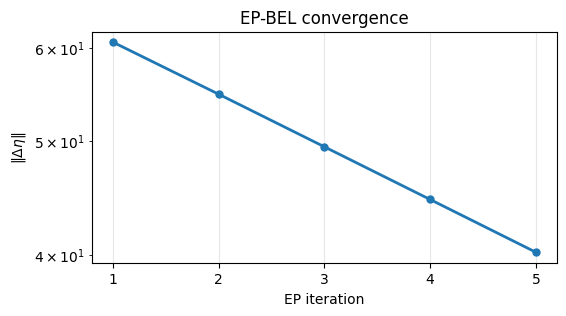

In [7]:
fig_conv, ax_conv = plt.subplots(figsize=(6, 3))
ax_conv.semilogy(
    range(1, len(ep_convergence) + 1),
    ep_convergence,
    "o-",
    linewidth=2,
    markersize=5,
)
ax_conv.set_xlabel("EP iteration")
ax_conv.set_ylabel(r"$\|\Delta\eta\|$")
ax_conv.set_title("EP-BEL convergence")
ax_conv.grid(True, alpha=0.3)
ax_conv.set_xticks(np.arange(1, len(ep_convergence) + 1))
plt.gca()

## Comparison: EP-BEL vs NUTS

We run NUTS on the same BEL posterior and compare the resulting samples with
the EP-BEL Gaussian approximation.

In [8]:
def bel_logdensity(params):
    """Log-posterior for NUTS sampling."""
    theta = params["theta"]
    lp = prior.log_prob(theta[0])
    log_pel, _ = calc_log_pel_and_weights(h_poisson, observed_y, theta)
    return jnp.where(jnp.isfinite(lp), jnp.squeeze(lp + log_pel), -jnp.inf)

In [9]:
import blackjax

def _run_nuts(key, log_density, init_positions, n_samples, n_warmup=1000):
    def inference_loop(rng_key, kernel, initial_state, num_samples):
        def one_step(state, rng_key):
            state, _ = kernel(rng_key, state)
            return state, state.position["theta"]

        keys = jax.random.split(rng_key, num_samples)
        _, samples = jax.lax.scan(one_step, initial_state, keys)
        return samples

    all_samples = []
    chain_keys = jr.split(key, len(init_positions))
    for i, init_pos in enumerate(init_positions):
        warmup_key, sample_key = jr.split(chain_keys[i])
        warmup = blackjax.window_adaptation(blackjax.nuts, log_density)
        (state, params), _ = warmup.run(warmup_key, init_pos, num_steps=n_warmup)
        kernel = blackjax.nuts(log_density, **params).step
        samples = inference_loop(sample_key, kernel, state, n_samples)
        all_samples.append(samples)

    all_theta = jnp.stack(all_samples, axis=0)
    return az.from_dict(posterior={"theta": np.asarray(all_theta)})

nuts_init = [
    {"theta": jnp.array([1.5])},
    {"theta": jnp.array([2.5])},
    {"theta": jnp.array([3.5])},
    {"theta": jnp.array([4.5])},
]
nuts_idata = _run_nuts(jr.key(42), bel_logdensity, nuts_init, 2000, n_warmup=2000)

In [10]:
az.summary(nuts_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta[0],2.78,0.23,2.383,3.245,0.004,0.003,3134.0,3736.0,1.0


### Posterior comparison

We overlay the EP-BEL Gaussian density with the NUTS posterior histogram.

<Axes: title={'center': 'EP-BEL Gaussian vs NUTS posterior'}, xlabel='$\\theta$', ylabel='Density'>

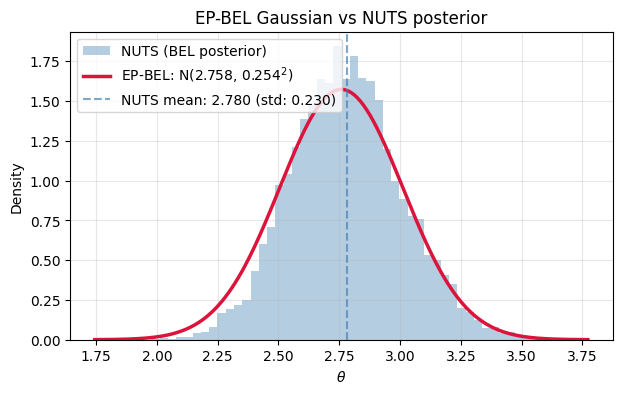

In [11]:
from scipy.stats import norm as scipy_norm

nuts_samples = nuts_idata.posterior["theta"].values.flatten()

fig_comp, ax_comp = plt.subplots(figsize=(7, 4))

# NUTS histogram
ax_comp.hist(
    nuts_samples,
    bins=50,
    density=True,
    alpha=0.4,
    color="steelblue",
    label="NUTS (BEL posterior)",
)

# EP-BEL Gaussian
_mu = float(np.array(ep_mu[0]))
_std = float(np.array(ep_std))
_x = np.linspace(_mu - 4 * _std, _mu + 4 * _std, 300)
ax_comp.plot(
    _x,
    scipy_norm.pdf(_x, _mu, _std),
    linewidth=2.5,
    color="crimson",
    label=f"EP-BEL: N({_mu:.3f}, {_std:.3f}" + r"$^2$)",
)

# NUTS mean/std for reference
nuts_mean = float(jnp.mean(jnp.array(nuts_samples)))
nuts_std = float(jnp.std(jnp.array(nuts_samples)))
ax_comp.axvline(
    nuts_mean,
    color="steelblue",
    linestyle="--",
    alpha=0.7,
    label=f"NUTS mean: {nuts_mean:.3f} (std: {nuts_std:.3f})",
)

ax_comp.set_xlabel(r"$\theta$")
ax_comp.set_ylabel("Density")
ax_comp.set_title("EP-BEL Gaussian vs NUTS posterior")
ax_comp.legend()
ax_comp.grid(True, alpha=0.3)
plt.gca()

## Summary

EP-BEL provides a fast, analytical Gaussian approximation to the Bayesian empirical
likelihood posterior. Key takeaways:

- **No MCMC needed**: once EP converges, the posterior is an explicit Gaussian $\mathcal{N}(\mu, \Sigma)$
- **Fast convergence**: typically a handful of iterations suffice
- **Accuracy**: the Gaussian approximation closely matches the NUTS posterior for well-behaved problems
- **Scalability**: site pooling ($D \ll n$) keeps the cost manageable; each site update requires one Laplace approximation